# School Notebooks (RU/EN) — raw COCO data
Pages + original polygon annotations + transcripts, straight from the dataset (no cropping/grouping of ours). Switch `REPO` between RU and EN.

In [1]:
import json
import zipfile
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
from PIL import Image
from huggingface_hub import snapshot_download

REPO = "ai-forever/school_notebooks_RU"   # or "ai-forever/school_notebooks_EN"
SPLIT = "train"                            # train / val / test

snap = Path(snapshot_download(REPO, repo_type="dataset"))
coco_path = next(p for p in snap.rglob("*.json") if SPLIT in p.stem.lower())
data = json.loads(coco_path.read_text(encoding="utf-8"))
assert "annotations" in data and "images" in data, f"{coco_path} is not COCO"
cats = {c["id"]: c["name"] for c in data["categories"]}
zf = zipfile.ZipFile(next(snap.rglob("*.zip")))
zip_names = {Path(n).name: n for n in zf.namelist()}
print(coco_path.name)
print("categories:", cats)
print("images:", len(data["images"]), "| annotations:", len(data["annotations"]))

Fetching 8 files:   0%|          | 0/8 [00:00<?, ?it/s]

annotations_train.json
categories: {0: 'pupil_text', 1: 'pupil_comment', 2: 'teacher_comment', 3: 'paper', 4: 'text_line'}
images: 1557 | annotations: 335962


In [2]:
COLORS = {0: "red", 1: "blue", 2: "green", 3: "gray", 4: "orange"}

def text_of(ann):
    attrs = ann.get("attributes") or {}
    return attrs.get("translation") or attrs.get("text") or ann.get("text") or ""

def polygons(ann):
    seg = ann.get("segmentation") or []
    polys = seg if seg and isinstance(seg[0], (list, tuple)) else [seg]
    return [list(zip(p[0::2], p[1::2])) for p in polys if p]

def open_page(img):
    return Image.open(zf.open(zip_names[Path(img["file_name"]).name])).convert("RGB")

def anns_of(image_id):
    return [a for a in data["annotations"] if str(a["image_id"]) == str(image_id)]

def show_page(index=0, only_cat=None):
    img = data["images"][index]
    page = open_page(img)
    anns = [a for a in anns_of(img["id"]) if only_cat is None or int(a["category_id"]) == only_cat]
    fig, ax = plt.subplots(figsize=(13, 18)); ax.imshow(page)
    for a in anns:
        for pts in polygons(a):
            ax.add_patch(Polygon(pts, fill=False, edgecolor=COLORS.get(int(a["category_id"]), "black"), lw=1.2))
    title = img["file_name"] + (f"  [{cats.get(only_cat)}]" if only_cat is not None else "")
    ax.set_title(title); ax.axis("off"); plt.show()
    return anns

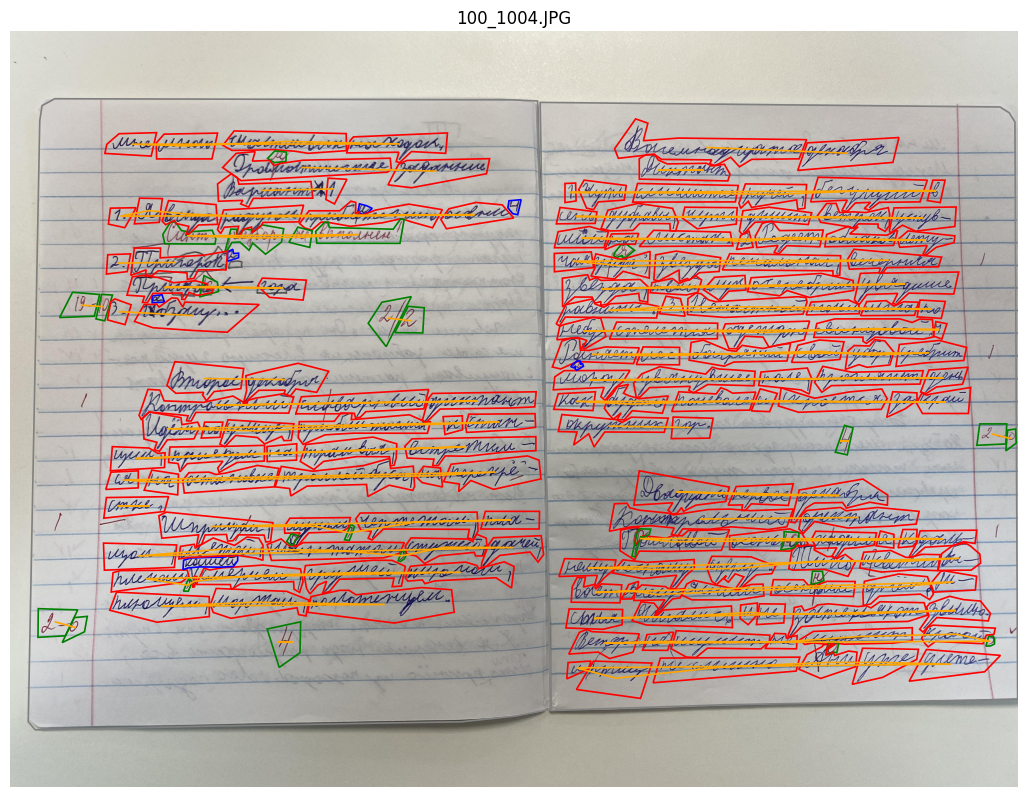

regions on this page: 245
pupil_text       grp=20   'улице,'
pupil_text       grp=20   'по'
pupil_text       grp=20   'Идём'
pupil_text       grp=17   'приедем'
pupil_text       grp=16   'остановке'
pupil_text       grp=16   'на'
pupil_text       grp=17   'щил,'
pupil_text       grp=16   'ся'
pupil_text       grp=14   'стке.'
pupil_text       grp=12   'Шприцом,'
pupil_text       grp=12   'лучом'
pupil_text       grp=12   'чертежом,'
pupil_text       grp=12   'пла-'
pupil_text       grp=8    'ключом,'
pupil_text       grp=8    'грушей,'
pupil_text       grp=22   'и'
pupil_text       grp=19   'гор.'
pupil_text       grp=22   'будти'
pupil_text       grp=19   'окружных'
pupil_text       grp=15   'Двадцать'
pupil_text       grp=15   'первое'
pupil_text       grp=15   'декабря'
pupil_text       grp=13   'диктант'
pupil_text       grp=13   'Контрольный'
pupil_text       grp=11   'даль-'
pupil_text       grp=5    'стья'
pupil_text       grp=5    'Осыпались'
pupil_comment    grp=None ''
pupil_

In [3]:
anns = show_page(index=13)
print("regions on this page:", len(anns))
for a in anns[:40]:
    print(f"{cats[int(a['category_id'])]:16} grp={a.get('group_id')!s:4} {text_of(a)!r}")

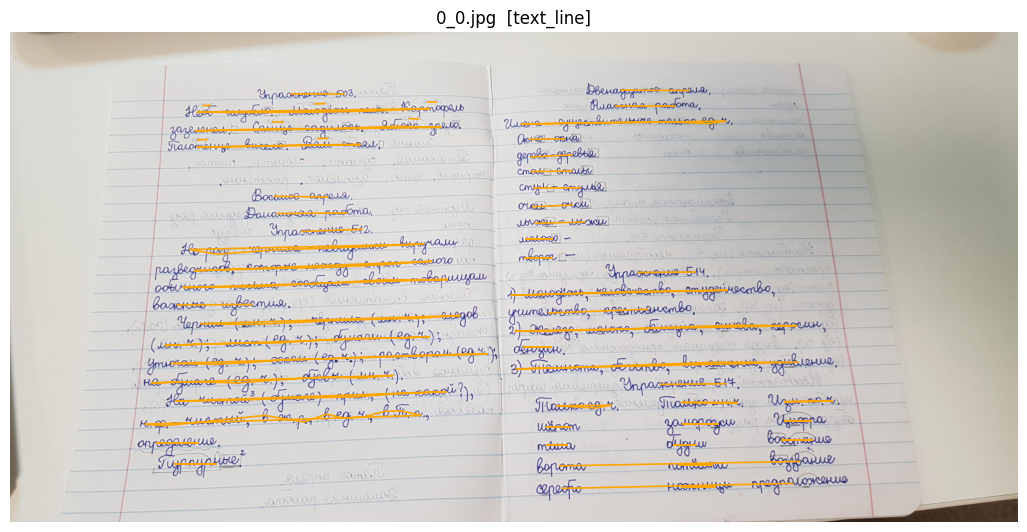

In [4]:
# only the text_line regions (category 4) — these define 'lines' (no transcript)
line_cat = next((cid for cid, name in cats.items() if name == "text_line"), 4)
show_page(index=0, only_cat=line_cat);

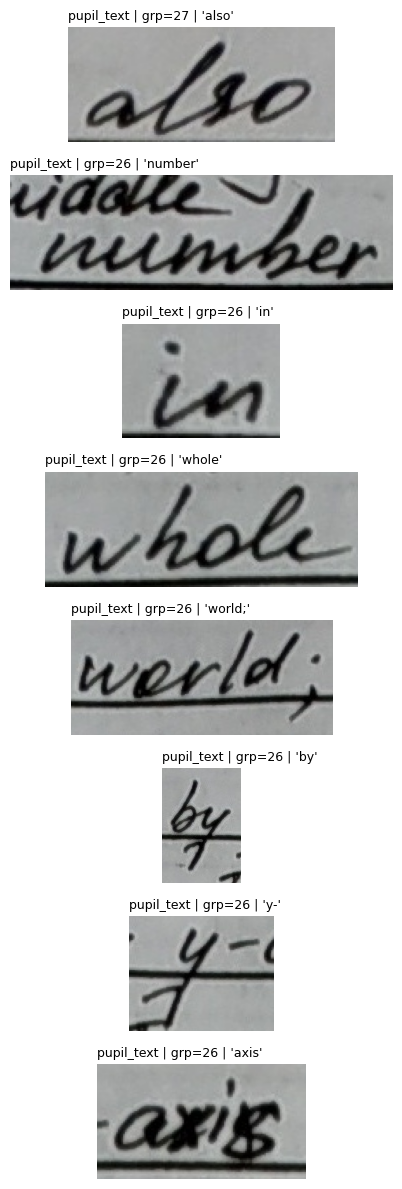

In [21]:
# raw per-annotation crops by bbox (no grouping) + their transcript — see image<->text directly
def bbox(pts_list):
    xs = [x for pts in pts_list for x, _ in pts]; ys = [y for pts in pts_list for _, y in pts]
    return min(xs), min(ys), max(xs), max(ys)

img = data["images"][0]; page = open_page(img)
regions = [a for a in anns_of(img["id"]) if text_of(a) and polygons(a)][:8]
fig, axes = plt.subplots(len(regions), 1, figsize=(11, 1.5 * len(regions)))
for ax, a in zip(axes, regions):
    x0, y0, x1, y1 = bbox(polygons(a))
    ax.imshow(page.crop((int(x0), int(y0), int(x1), int(y1)))); ax.axis("off")
    ax.set_title(f"{cats[int(a['category_id'])]} | grp={a.get('group_id')} | {text_of(a)!r}", fontsize=9, loc="left")
plt.tight_layout(); plt.show()

In [7]:
# how many regions share a group_id (a 'line') — and the combined text per group
from collections import defaultdict
groups = defaultdict(list)
for a in anns_of(data["images"][0]["id"]):
    if text_of(a):
        groups[a.get("group_id")].append(a)
for gid, items in list(groups.items())[:15]:
    print(f"grp {gid!s:4} n={len(items):2} | {' '.join(text_of(a) for a in items)!r}")

grp 9    n= 6 | 'прил., (на какой?), (бумаге) - чистой На'
grp 7    n=12 | 'п., П. в ч., ед. в р., ж. в чистый, н. ф. -'
grp 52   n= 2 | 'ж. р.'
grp 21   n= 5 | 'сообщали товарищам своим обычного письма'
grp 4    n= 1 | 'определение.'
grp 3    n= 1 | 'Пурпурные.'
grp 41   n= 2 | 'Упражнение 503.'
grp 39   n= 5 | 'Небо голубело.. Молодёжь пела. Картофель'
grp 37   n= 5 | 'Яблоко зрело. зазеленел. Солнце садилось.'
grp 25   n= 5 | 'невидимки раз чернила - выручали Не'
grp 35   n= 4 | 'Полотенце висело. Рояль стоял.'
grp 42   n= 2 | 'Двенадцатое апреля.'
grp 40   n= 2 | 'работа. Классная'
grp 38   n= 5 | 'Имена существительные только ед. ч.'
grp 36   n= 2 | 'Окно - окна'
